# Data Preprocessing Part 2


* Data intergration

* Data transformation [Ref] https://www.kaggle.com/code/nargisbegum82/all-about-feature-transformation#Standardization

* Data reduction

# Load dataframes

In [1]:
import numpy as np
import pandas as pd


from google.colab import drive
drive.mount('/content/drive')

df_salary = pd.read_csv('/content/drive/MyDrive/Dataset/salary_cleaned.csv') #load the csv dataset into a 'dataframe' df

#Convert "salary" string to integers
#df_salary['Salary'] = df_salary['Salary'].replace(',','',regex=True) #this replace the comma ',' in 55,000 to 55000
#df_salary['Salary'] = df_salary['Salary'].astype(int) # this convert the column datatypes from object into numbers , in this case integer



df_salary.head()

Mounted at /content/drive


,USERID,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender
0,8683,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman
1,3880,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000.0,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman
2,8898,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman
3,4441,4/27/2021 11:03:01,45-54,Computing or Tech,Systems Analyst,112000.0,10000.0,USD,US,Missouri,St. Louis,21 - 30 years,21 - 30 years,College degree,Woman
4,7537,4/27/2021 11:03:02,35-44,"Accounting, Banking & Finance",Senior Accountant,45000.0,0.0,USD,United States,Florida,Palm Coast,21 - 30 years,21 - 30 years,College degree,Woman


In [ ]:
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13404 entries, 0 to 13403
Data columns (total 15 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   USERID                              13404 non-null  int64  
 1   Timestamp                           13403 non-null  object 
 2   Age                                 13403 non-null  object 
 3   Industry                            13403 non-null  object 
 4   Job title                           13403 non-null  object 
 5   Salary                              13403 non-null  float64
 6   Compensation                        13403 non-null  float64
 7   Currency                            13403 non-null  object 
 8   Country                             13403 non-null  object 
 9   State                               13403 non-null  object 
 10  City                                13403 non-null  object 
 11  Overall years of experience         13403

# 1. Data Intergration

## 1.1 Load New dataframe

In [2]:
df_xtra_info = pd.read_csv('/content/drive/MyDrive/Dataset/xtra_info.csv') #load the csv dataset into a 'dataframe' df

df_xtra_info.head()

,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
0,8683,2.990627,4583.333333,2437.0
1,3880,2.288131,5166.666667,740.0
2,8898,3.903324,5000.000000,3806.0
3,4441,2.470852,9333.333333,4691.0
4,7537,3.559457,3750.000000,4580.0


In [ ]:
df_xtra_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13404 entries, 0 to 13403
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   USERID             13404 non-null  int64  
 1   CGPA               13403 non-null  float64
 2   Salary_month_USD   13403 non-null  float64
 3   Special Bonus_GBP  13403 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 419.0 KB


In [4]:
df_master = pd.concat([df_salary,df_xtra_info],axis=1)


In [5]:
df_master.head()

,USERID,Timestamp,Age,Industry,Job title,Salary,Compensation,Currency,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,USERID,CGPA,Salary_month_USD,Special Bonus_GBP
0,8683,4/27/2021 11:02:10,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,USD,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,8683,2.990627,4583.333333,2437.0
1,3880,4/27/2021 11:02:41,25-34,Nonprofits,Program Manager,62000.0,3000.0,USD,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,3880,2.288131,5166.666667,740.0
2,8898,4/27/2021 11:02:42,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,USD,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,8898,3.903324,5000.000000,3806.0
3,4441,4/27/2021 11:03:01,45-54,Computing or Tech,Systems Analyst,112000.0,10000.0,USD,US,Missouri,St. Louis,21 - 30 years,21 - 30 years,College degree,Woman,4441,2.470852,9333.333333,4691.0
4,7537,4/27/2021 11:03:02,35-44,"Accounting, Banking & Finance",Senior Accountant,45000.0,0.0,USD,United States,Florida,Palm Coast,21 - 30 years,21 - 30 years,College degree,Woman,7537,3.559457,3750.000000,4580.0


<Axes: >

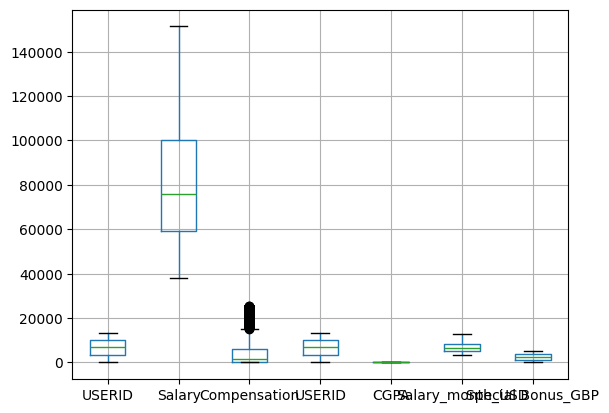

In [8]:
df_master.boxplot()

In [ ]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13404 entries, 0 to 13403
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   USERID                              13404 non-null  int64  
 1   Timestamp                           13403 non-null  object 
 2   Age                                 13403 non-null  object 
 3   Industry                            13403 non-null  object 
 4   Job title                           13403 non-null  object 
 5   Salary                              13403 non-null  float64
 6   Compensation                        13403 non-null  float64
 7   Currency                            13403 non-null  object 
 8   Country                             13403 non-null  object 
 9   State                               13403 non-null  object 
 10  City                                13403 non-null  object 
 11  Overall years of experience         13403

## 1.2 Drop Derivable data

Nov 2024 Update: Have to encode the categorical data first, and then do correlation analysis.



In [ ]:
df_master[['Salary','Compensation']].corr()

# Identify categorical columns
categorical_cols = df_master.select_dtypes(include=['object', 'category']).columns

# Apply one-hot encoding
df_master2 = pd.get_dummies(df_master, columns=categorical_cols, prefix=categorical_cols)


#df_master[['Industry','Salary']].corr()
df_master2.corr() #correlation analysis


In [ ]:
df_master.plot.scatter('Salary','Salary_month_USD')

In [ ]:
df_master = df_master.drop(columns='Salary_month_USD')
df_master.info()

## 1.3 Object Identification

* Convert Special Bonus_GBP column to USD

In [ ]:
df_master['Special Bonus_GBP'] = df_master['Special Bonus_GBP'] * 1.22 # currency rate 1GBP=1.22 USD


df_master.head()

In [ ]:
df_master = df_master .rename(columns={'Special Bonus_GBP': 'Special_Bonus_USD'})
df_master.head()

# 2. Data transformation - Normalization

* Min-max normalization
* Zscore/Standard normalization


### 2.1 Min-max normalization

* [Ref] https://www.geeksforgeeks.org/data-pre-processing-wit-sklearn-using-standard-and-minmax-scaler/

* CAUTION: Normalization should only be applied after splitting the datas into  training dataset and test dataset!!(Else Will affect the performance of Machine Learning)

In [ ]:
#Before min-max normalization

df_master.hist(figsize=(20,10))

#df_master['Salary'].hist()
#df_master['Compensation'].hist()
#df_master['Special_Bonus_USD'].hist()


In [ ]:
from sklearn import preprocessing
m=preprocessing.MinMaxScaler(feature_range=(0, 1))

# apply normalization techniques
df_master_norm_min_max = df_master.copy()


df_master_norm_min_max[['Salary','Compensation','Special_Bonus_USD']]=m.fit_transform(df_master_norm_min_max[['Salary','Compensation','Special_Bonus_USD']])

#After min-max normalization
df_master_norm_min_max.head()

In [ ]:
df_master_norm_min_max.hist(figsize=(20,10))

## 2.2 Z-score normalization

* [Ref]https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

In [ ]:
m=preprocessing.StandardScaler()

# apply normalization techniques
df_master_norm_std_scaler = df_master.copy()


df_master_norm_std_scaler[['Salary','Compensation','Special_Bonus_USD']]=m.fit_transform(df_master_norm_std_scaler[['Salary','Compensation','Special_Bonus_USD']])

#After min-max normalization
df_master_norm_std_scaler.hist(figsize=(20,10))

# Data Reduction

## 2.1 Aggregation

* aggregate
* groupby
* aggregate and groupby
* sort

In [ ]:
df_master.head()

In [ ]:
df_master.agg(['min'])
#df_master['Salary'].agg(['min'])

In [ ]:
#df_master.info()
df_master.describe()

In [ ]:
#Let's say we want to groupby city. Different cities should have different salary ranges. New York vs Wisconsin


df_master['City'].unique()
i=1
for c in df_master['City'].unique():
  print(f'{i}: {c}')
  i+=1



* [Ref] https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.aggregate.html

In [ ]:
#df_by_city = df_master.groupby('City').aggregate(['min','max','mean'])

#df_master.groupby('City').aggregate(['min'])
#df_master.groupby('City').aggregate(['min','max','mean'])

df_by_city = df_master.groupby('City').aggregate('mean')

In [ ]:
df_by_city = df_by_city.drop(columns = ['USERID'])


# What is the average salary by city ?


In [ ]:
df_by_city.sample(5)

# This bar plot doesn't show us anything

In [ ]:
df_by_city.plot.bar(y='Salary',figsize=(50,10),use_index=True,rot=90)

In [ ]:
df_by_city = df_by_city[df_by_city['Salary']>120000]
df_by_city.info()

*https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html

# Which city has the highest average salary, and which city has the lowest?

In [ ]:
df_by_city = df_by_city.sort_values(by='Salary',ascending=False)
df_by_city.plot.bar(y='Salary',figsize=(30,10),use_index=True,rot=90)

In [ ]:
df_master['Currency'].unique()

list_curr = df_master['Currency'].unique()

for i in list_curr:
  count = df_master[df_master['Currency']==i]['Currency'].count()
  print(f'{i}: {count}')


df_master.apply()